# Milestone 2: Threat Index Creation and Testing

In [2]:
from herbie import Herbie
import pandas as pd, numpy as np, xarray as xr
import matplotlib.pyplot as plt

## Data download

In [4]:
run = pd.Timestamp("2026-03-14-00")

In [5]:
H = Herbie(run, model="ifs", product="oper", fxx=6, save_dir='./data/', overwrite=True)

✅ Found ┊ model=ifs ┊ product=oper ┊ 2026-Mar-14 00:00 UTC F06 ┊ GRIB2 @ google ┊ IDX @ google


In [22]:
ss = "(2d|2t|tcc|10u|10v):"

In [23]:
H.inventory(ss)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)


,grib_message,start_byte,end_byte,range,reference_time,valid_time,step,param,levelist,levtype,number,domain,expver,class,type,stream,search_this
75,76,56293047,56841563,56293047-56841563,2026-03-14,2026-03-14 06:00:00,0 days 06:00:00,tcc,NaN,sfc,NaN,g,0001,od,fc,oper,:tcc:sfc:g:0001:od:fc:oper
80,81,59996228,60860303,59996228-60860303,2026-03-14,2026-03-14 06:00:00,0 days 06:00:00,10u,NaN,sfc,NaN,g,0001,od,fc,oper,:10u:sfc:g:0001:od:fc:oper
90,91,68159563,69013568,68159563-69013568,2026-03-14,2026-03-14 06:00:00,0 days 06:00:00,10v,NaN,sfc,NaN,g,0001,od,fc,oper,:10v:sfc:g:0001:od:fc:oper
95,96,73744336,74401591,73744336-74401591,2026-03-14,2026-03-14 06:00:00,0 days 06:00:00,2t,NaN,sfc,NaN,g,0001,od,fc,oper,:2t:sfc:g:0001:od:fc:oper
102,103,78438657,79117976,78438657-79117976,2026-03-14,2026-03-14 06:00:00,0 days 06:00:00,2d,NaN,sfc,NaN,g,0001,od,fc,oper,:2d:sfc:g:0001:od:fc:oper


In [25]:
datasets = H.xarray(ss)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)


Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly

In [31]:
ds = xr.merge(datasets, compat='override')
ds = ds.sel(longitude=slice(-130,-60), latitude=slice(55,20))

In [33]:
ds.to_netcdf('ecmwf_ms2.nc')

## Index Creation

In [2]:
ds = xr.open_dataset('ecmwf_ms2.nc')

sh: 1: getfattr: not found


In [3]:
ds

<xarray.Dataset> Size: 796kB
Dimensions:              (latitude: 141, longitude: 281)
Coordinates:
  * latitude             (latitude) float64 1kB 55.0 54.75 54.5 ... 20.25 20.0
  * longitude            (longitude) float64 2kB -130.0 -129.8 ... -60.25 -60.0
    time                 datetime64[ns] 8B ...
    step                 timedelta64[ns] 8B ...
    entireAtmosphere     float64 8B ...
    valid_time           datetime64[ns] 8B ...
    gribfile_projection  float64 8B ...
    heightAboveGround    float64 8B ...
Data variables:
    tcc                  (latitude, longitude) float32 158kB ...
    u10                  (latitude, longitude) float32 158kB ...
    v10                  (latitude, longitude) float32 158kB ...
    t2m                  (latitude, longitude) float32 158kB ...
    d2m                  (latitude, longitude) float32 158kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    model:                   ifs
    product:                 oper
    description:             ECMWF Open Data - Integrated Forecast System
    remote_grib:             https://storage.googleapis.com/ecmwf-open-data/2...
    local_grib:              data/ifs/20260314/subset_73b25887__2026031400000...
    search:                  (2d|2t|tcc|10u|10v):

### Threat Index Example: Pool Use Index
- Range: 0 to 100
- 0 = no pool use
- 100 = best possible
- I'll construct the index from 0-1 first, then multiply by 100

Best possible conditions:
- temperature bwteeen 80 - 90 F
- less than 50% cloud cover
- dew point between 40 - 70 F
- wind speed less than 10 kt

Weighting:
- temperature: 60% 
- wind: 20 %
- dew point: 10 %
- clouds: 10 %

Temperature contribution:
- 0 when T < 60 F
- 1 when 80 <= T <= 90
- 0.5 when T >= 110
- Linear slope from 60 - 80 and 90 - 110

In [4]:
temp_f = (ds['t2m'].values - 273.15)*(9/5) + 32

NameError: name 'ds' is not defined

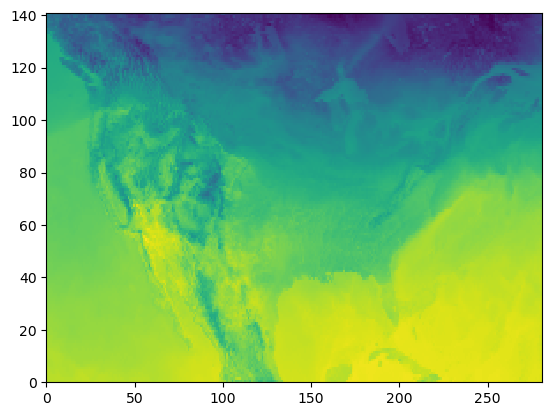

In [5]:
plt.pcolormesh(np.flipud(temp_f))

In [7]:
temp_f.max()

np.float32(82.43993)

#### Calculating the temperature contribution
This is just one approach that can work:
- start with an array of all zeros
- identify the grid points that match the given criteria (e.g., between 80 and 90). Assign the appropriate values to those particular grid points

In [3]:
# Start with all contributions set to 0
temp_contribution = np.zeros_like(temp_f)

# 60 <= T < 80 : linear increase from 0 to 1
mask = (temp_f >= 60) & (temp_f < 80)
temp_contribution[mask] = (temp_f[mask] - 60) / 20

# 80 <= T <= 90 : contribution = 1
mask = (temp_f >= 80) & (temp_f <= 90)
temp_contribution[mask] = 1.0

# 90 < T < 110 : linear decrease from 1 to 0.5
mask = (temp_f > 90) & (temp_f < 110)
temp_contribution[mask] = 1.0 - (temp_f[mask] - 90) * (0.5 / 20)

# T >= 110 : contribution = 0.5
mask = temp_f >= 110
temp_contribution[mask] = 0.5

NameError: name 'temp_f' is not defined

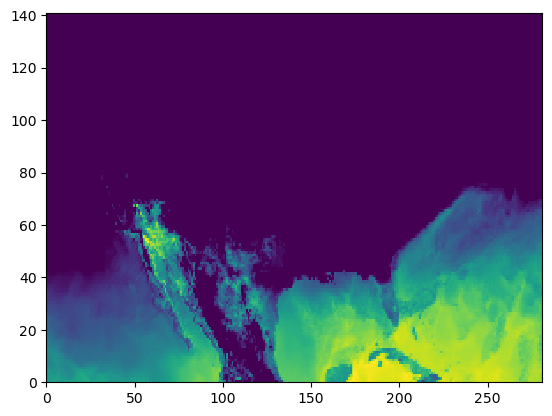

In [9]:
plt.pcolormesh(np.flipud(temp_contribution))

#### Calculating the final index
Once you've calculated the components of your index, the final step is weighting each component to yield the final index.

In [10]:
# Assuming we have defined the other contributions
# Dummy values here
t_cont = 0.8
d_cont = 0.6
cc_cont = 0.7
w_cont = 0.2

PUI = (t_cont*0.6 + w_cont*0.2 + cc_cont*0.1 + d_cont*0.1)*100
PUI

64.99999999999999